### Imports

In [ ]:
import json
import os
import re
import string
from typing import List

from docling.document_converter import DocumentConverter
from IPython.display import Image, display
from json_repair import repair_json
from langchain.prompts import PromptTemplate
from langchain_chroma import Chroma
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_core.output_parsers import JsonOutputParser
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_ollama import ChatOllama
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict

In [ ]:
embeddings = HuggingFaceEmbeddings(
    model_name="nomic-ai/nomic-embed-text-v1.5",
    model_kwargs={"device": "cuda", "trust_remote_code": True},
)

vector_db = Chroma(
    collection_name="rag-chroma",
    persist_directory="./chroma",
    embedding_function=embeddings,
)

<All keys matched successfully>


### LLM Definitions

In [ ]:
relations_extractor_llm = "llama3.1"
relations_json_formatter_llm = "llama3.1"
summary_llm = "llama3.1"
summary_json_formatter_llm = "llama3.1"
name_date_llm = "llama3.1"
name_date_json_formatter_llm = "llama3.1"
questions_llm = "llama3.1"
questions_json_formatter_llm = "llama3.1"

### Relationship Extractor

In [ ]:
llm = ChatOllama(
    base_url="https://ollama.pplus.ai",
    model=relations_extractor_llm,
    format="json",
    temperature=0,
)

prompt = PromptTemplate(
    template="""
    You are an expert in analyzing financial circulars and extracting key information. Your task is to carefully read the given PDF content from a circular and extract specific details in a structured JSON format. Start extracting relationships after the Title of the document.

    Relationships in the context is defined as mention of a particular document, circular, notification, laws, acts. in the current document. Extract the most meaningful single word relationship mentioned in the document. While mentioning the document, please only include the title of the document, date and other identifiers are not required. 
    
    Example of relationships include: superseded, amended, overturned, replaced, etc.
    
    <JSON Output Structure>
    "relations": {{
      "Document 1": "Relationship with current document",
      "Document 2": "Relationship with current document"
    }}
    </JSON Structure>

    <PDF Page Content>
    {pdf_content}
    </PDF Page Content>
    """,
    input_variables=["pdf_content"],
)

page_relations_extractor_chain = prompt | llm | JsonOutputParser()

In [ ]:
llm = ChatOllama(
    base_url="https://ollama.pplus.ai",
    model=relations_json_formatter_llm,
    format="json",
    temperature=0,
)

prompt = PromptTemplate(
    template="""
    Given the Required Output JSON schema, you are required to format by combining individual string output into a single structured JSON format. Remove or Merge any duplicate or redundant information.

    <Unformatted Input>
    {unformatted_input}
    </Unformatted Input>

    <Formatted JSON Output Schema>
    "relations": {{
      "Document 1": "Relationship with current document",
      "Document 2": "Relationship with current document"
    }}
    </Formatted JSON Output Schema>

    """,
    input_variables=["pdf_content"],
)

relations_json_formatter_chain = prompt | llm | JsonOutputParser()

In [ ]:
# pdf = PyPDFLoader(
#     "/workspace/legalAgent/langraphKG/circulars/Existing Circular.pdf"
# ).load()
# output = ""

# for i in range(len(pdf)):
#     page_output = page_relations_extractor_chain.invoke(
#         {"pdf_content": pdf[i].page_content}
#     )
#     page_output = str(page_output)
#     output += page_output + "\n"

# output = relations_json_formatter_chain.invoke({"unformatted_input": output})
# output = repair_json(str(output))
# print(output)

{"relations": {"A.P. (DIR Series) Circular No. 22": "invited to", "A.P. (DIR Series) Circular No. 24": "superseded", "A.P. (DIR Series) Circular No. 26": "superseded", "Notification No. FEMA.396/2019-RB": "superseded", "SEBI (Foreign Portfolio Investors) Regulations, 2014": "amended", "Companies Act, 2013": "referenced", "Insolvency and Bankruptcy Code, 2016": "referenced", "A.P. (DIR Series) Circular No. 13 dated July 23, 2014": "superseded", "A.P. (DIR Series) Circular No. 71 dated February 03, 2015": "amended", "A.P. (DIR Series) Circular No.18 dated January 23, 2020": "amended", "A.P. (DIR Series) Circular No.12 dated February 26, 2021": "inserted", "FPI shall not exceed 30%5 of the total investment of that FPI in corporate bonds": "Amended", "A.P. (DIR Series) Circular No. 19 dated October 6, 2015": "Superseded", "Circular No. H.O.(CCIL)/2019-20/1003": "amended", "Circular No. H.O.(CCIL)/2018-19/1010": "superseded", "A.P. (DIR Series) Circular No. 19": "amended", "A.P. (DIR Series

### Summary Generator

In [ ]:
llm = ChatOllama(
    base_url="https://ollama.pplus.ai",
    model=summary_llm,
    format="json",
    temperature=0,
)

prompt = PromptTemplate(
    template="""
    You are an expert in analyzing financial circulars and extracting key information. Your task is to carefully read the given PDF content from a circular and extract specific details in a structured JSON format. 

    Summarize the content of the document. The summary should be concise and capture the essence of the document.
    

    <JSON Output Structure>
    "summary": "summary of the document"
    </JSON Structure>

    <PDF Page Content>
    {pdf_content}
    </PDF Page Content>
    """,
    input_variables=["pdf_content"],
)

summary_chain = prompt | llm | JsonOutputParser()

In [ ]:
llm = ChatOllama(
    base_url="https://ollama.pplus.ai",
    model=summary_json_formatter_llm,
    format="json",
    temperature=0,
)

prompt = PromptTemplate(
    template="""
    Given the Required Output JSON schema, you are required to format by using the page wise summary to generate a single complete summary for the document and format it in JSON format. Remove or Merge any duplicate or redundant information.

    <Unformatted Input>
    {unformatted_input}
    </Unformatted Input>

    <Formatted JSON Output Schema>
    "summary": "summary of the document"
    </Formatted JSON Output Schema>
    """,
    input_variables=["pdf_content"],
)

summary_json_formatter_chain = prompt | llm | JsonOutputParser()

In [ ]:
# pdf = PyPDFLoader('/workspace/fmc/agenticKG/langraphApproach/Existing Circular.pdf').load()
# output = ""

# for i in range(len(pdf)):
#     page_output = summary_chain.invoke({'pdf_content': pdf[i].page_content})
#     page_output = str(page_output)
#     output += page_output + "\n"

# output = summary_json_formatter_chain.invoke({'unformatted_input': output})
# output = repair_json(str(output))
# print(output)

### Name and Date Extractor

In [ ]:
llm = ChatOllama(
    base_url="https://ollama.pplus.ai",
    model=name_date_llm,
    format="json",
    temperature=0,
)

prompt = PromptTemplate(
    template="""
    You are an expert in extracting key information. Your task is to carefully read the given PDF content from a circular and extract specific details in a structured JSON format. 

    1. Name: Provide the name of the document mentioned at the very start not including RBI/Year/No
    2. Date of Issue: Find and extract the date when the circular was issued.
    
    <JSON Output Structure>
    "name": "The full name of the document without '/'",
    "date_of_issue": "The date when the circular was issued in DD/MM/YYYY format",
    </JSON Structure>

    <PDF Page Content>
    {pdf_content}
    </PDF Page Content>
    """,
    input_variables=["pdf_content"],
)

name_date_chain = prompt | llm | JsonOutputParser()

In [ ]:
# pdf = PyPDFLoader('/workspace/fmc/agenticKG/langraphApproach/Existing Circular.pdf').load()
# output = name_date_chain.invoke({'pdf_content': pdf[0].page_content})
# print(output)

### Questions Generator

In [ ]:
llm = ChatOllama(
    base_url="https://ollama.pplus.ai",
    model=questions_llm,
    format="json",
    temperature=0,
)

prompt = PromptTemplate(
    template="""
    You are retrieval augmented generation model. Your task is to generate a set of questions based on the given PDF content. The questions should be relevant to the content and should be in a structured JSON format. The questions generated would be used to improve retrieval quality during vector search. So make sure the questions are relevant and meaningful which would be frequently asked for the provided content. Only include specific question pertaining the content provided and no general questions.

    
    <JSON Output Structure>
    "questions": [
      "Question 1",
      "Question 2",
      "Question 3"
    ]
    </JSON Structure>
    
    <PDF Page Content>
    {pdf_content}
    </PDF Page Content>
    """,
    input_variables=["pdf_content"],
)

questions_gen_chain = prompt | llm | JsonOutputParser()

In [ ]:
llm = ChatOllama(
    base_url="https://ollama.pplus.ai",
    model=questions_json_formatter_llm,
    format="json",
    temperature=0,
)

prompt = PromptTemplate(
    template="""
    Given the Required Output JSON schema, you are required to format by using the page wise summary to generate a single complete summary for the document and format it in JSON format. Remove or Merge any duplicate or redundant information.

    <Unformatted Input>
    {unformatted_input}
    </Unformatted Input>

    <Formatted JSON Output Schema>
    "questions": [
      "Question 1",
      "Question 2",
      "Question 3"
    ]
    </Formatted JSON Output Schema>
    """,
    input_variables=["pdf_content"],
)

questions_json_formatter_chain = prompt | llm | JsonOutputParser()

### State Definition

In [ ]:
class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        path: The document path.
        name: The name of the document.
        date_of_issue: The date when the circular was issued.
        summary: The summary of the document.
        relations: The relationships between the current document and other documents.
    """

    path: str
    name: str
    date_of_issue: str
    summary: str
    relations: List[str]
    questions: List[str]

### Node Definitions

In [ ]:
def extract_name_date(state):
    """
    Extract name and date of issue

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New keys added to state, name and date_of_issue, that contain the name and date of issue
    """
    print("---EXTRACTING NAME AND DATE---")
    pdf = PyPDFLoader(state["path"]).load()
    output = name_date_chain.invoke({"pdf_content": pdf[0].page_content})
    state["name"] = output["name"].replace("/", " ")
    state["date_of_issue"] = output["date_of_issue"]
    return state


def extract_relationships(state):
    """
    Extract relationships

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, relations, that contains the relationships between the current document and other documents
    """
    print("---EXTRACTING RELATIONSHIPS---")
    pdf = PyPDFLoader(state["path"]).load()
    output = ""
    for i in range(len(pdf)):
        page_output = page_relations_extractor_chain.invoke(
            {"pdf_content": pdf[i].page_content}
        )
        page_output = str(page_output)
        output += page_output + "\n"
    output = relations_json_formatter_chain.invoke({"unformatted_input": output})
    output = repair_json(str(output))
    output = json.loads(output)
    state["relations"] = output["relations"]
    return state


def summarize_document(state):
    """
    Summarize the document

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, summary, that contains the summary of the document
    """
    print("---SUMMARIZING DOCUMENT---")
    pdf = PyPDFLoader(state["path"]).load()
    output = ""
    for i in range(len(pdf)):
        page_output = summary_chain.invoke({"pdf_content": pdf[i].page_content})
        page_output = str(page_output)
        output += page_output + "\n"
    output = summary_json_formatter_chain.invoke({"unformatted_input": output})
    output = repair_json(str(output))
    output = json.loads(output)
    state["summary"] = output["summary"]
    return state


def generate_questions(state):
    """
    Generate questions

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, questions, that contains the questions generated from the document
    """
    print("---GENERATING QUESTIONS---")
    pdf = PyPDFLoader(state["path"]).load()
    output = ""
    for i in range(len(pdf)):
        page_output = questions_gen_chain.invoke({"pdf_content": pdf[i].page_content})
        page_output = str(page_output)
        output += page_output + "\n"
    output = questions_json_formatter_chain.invoke({"unformatted_input": output})
    output = repair_json(str(output))
    output = json.loads(output)
    state["questions"] = output["questions"]
    return state


def format_output(state):
    """
    Format the output

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): The formatted output
    """
    print("---FORMATTING OUTPUT---")
    output = {
        "name": state["name"],
        "date_of_issue": state["date_of_issue"],
        "summary": state["summary"],
        "relations": state["relations"],
        "questions": state["questions"],
    }
    output = repair_json(str(output))
    output = json.loads(output)

    output_path = "./output/"
    os.makedirs(output_path, exist_ok=True)
    with open(f"{output_path}{state['name']}.json", "w") as f:
        json.dump(output, f)

    printable = set(string.printable)
    converter = DocumentConverter()
    result = converter.convert(state["path"])
    doc = result.document.export_to_markdown()
    doc = doc.replace("<!-- image -->", "")
    doc = "".join(filter(lambda x: x in printable, doc))
    doc = re.sub(r"\n+", "\n", doc)
    doc = re.sub(r"https?://\S+|www\.\S+", "", doc)
    doc = Document(
        page_content=doc,
        metadata={
            "source_path": state["path"],
            "name": state["name"],
            "date_of_issue": state["date_of_issue"],
        },
    )
    ids = vector_db.add_documents(documents=[doc])
    print(f"Added document with ids: {ids}")

    return state

### Graph Building

In [ ]:
workflow = StateGraph(GraphState)

workflow.add_node("name_date", extract_name_date)
workflow.add_node("relationships", extract_relationships)
workflow.add_node("doc_summary", summarize_document)
workflow.add_node("output_formatting", format_output)
workflow.add_node("generate_questions", generate_questions)

workflow.add_edge(START, "name_date")
workflow.add_edge("name_date", "relationships")
workflow.add_edge("relationships", "doc_summary")
workflow.add_edge("doc_summary", "generate_questions")
workflow.add_edge("generate_questions", "output_formatting")
workflow.add_edge("output_formatting", END)

app = workflow.compile()

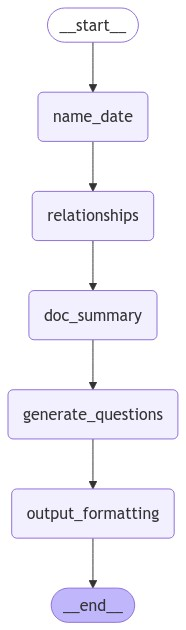

In [ ]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

### Executing Graph

In [ ]:
directory_path = "circulars/"
for filename in os.listdir(directory_path):
    print(f"Processing {filename}...")
    inputs = {
        "path": f"{directory_path}{filename}",
        "name": "",
        "date_of_issue": "",
        "summary": "",
        "relations": [],
    }
    for output in app.stream(inputs):
        for key, value in output.items():
            print("---" * 5)
            print(f"{key}: {value}")
            print("---" * 5)

Processing Withdrawn Circular 2.pdf...
---EXTRACTING NAME AND DATE---
---------------
name_date: {'path': 'circulars/Withdrawn Circular 2.pdf', 'name': 'A.P. (DIR Series) Circular No. 26', 'date_of_issue': '01/05/2018', 'summary': '', 'relations': []}
---------------
---EXTRACTING RELATIONSHIPS---
---------------
relationships: {'path': 'circulars/Withdrawn Circular 2.pdf', 'name': 'A.P. (DIR Series) Circular No. 26', 'date_of_issue': '01/05/2018', 'summary': '', 'relations': {'FEMA.20/2000-RB': 'amended', 'AP (DIR Series) Circular No. 24 dated April 27, 2018': 'amended', 'Companies Act, 2013': 'referenced', 'Foreign Exchange Management Act, 1999 (42 of 1999)': 'issued under'}}
---------------
---SUMMARIZING DOCUMENT---
---------------
doc_summary: {'path': 'circulars/Withdrawn Circular 2.pdf', 'name': 'A.P. (DIR Series) Circular No. 26', 'date_of_issue': '01/05/2018', 'summary': 'The Reserve Bank of India (RBI) has issued a circular to all authorized persons regarding the review of in

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Added document with ids: ['1415e3b9-f91c-4074-91d1-4b976ad826f6']
---------------
output_formatting: {'path': 'circulars/Withdrawn Circular 2.pdf', 'name': 'A.P. (DIR Series) Circular No. 26', 'date_of_issue': '01/05/2018', 'summary': 'The Reserve Bank of India (RBI) has issued a circular to all authorized persons regarding the review of investment by Foreign Portfolio Investors (FPIs) in debt. The circular aims to bring consistency across debt categories, and stipulates that investments by FPIs in corporate bonds with residual maturity below one year shall not exceed 20% of the total investment of that FPI in corporate bonds. The circular clarifies provisions related to Foreign Portfolio Investors (FPIs) investments in treasury bills, securities with residual maturity below one year, and corporate bonds, including concentration limits and online monitoring of G-sec limits. The document contains directions applicable with immediate effect, issued under sections 10(4) and 11(1) of the F

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Added document with ids: ['cd9349b7-f54d-43fb-a84e-60e9789f87af']
---------------
output_formatting: {'path': 'circulars/Withdrawn Circular.pdf', 'name': 'A.P. (DIR Series) Circular No. 24', 'date_of_issue': 'April 27, 2018', 'summary': 'The Reserve Bank of India (RBI) has issued a circular revising the framework for Foreign Portfolio Investors (FPI) investments in debt, effective April 27, 2018. The changes include the withdrawal of minimum residual maturity requirements for Central Government securities and State Development Loans, subject to certain conditions. The circular revises investment limits and rules for Foreign Portfolio Investors (FPIs) in corporate bonds, Central Government securities, and debt securities. It also introduces online monitoring of G-sec utilization limits and concentration limits for FPI investments. The circular outlines new investment limits for Foreign Portfolio Investors (FPIs), including a 2.5% increase in portfolio size, and restrictions on investmen

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Added document with ids: ['c1a3cfb0-9ef3-4ea5-88ca-b1b5817bc474']
---------------
output_formatting: {'path': 'circulars/Existing Circular 2016.pdf', 'name': 'A.P. (DIR Series) Circular No. 19', 'date_of_issue': 'November 17, 2016', 'summary': 'The Reserve Bank of India (RBI) has announced that Foreign Portfolio Investors (FPIs) are now permitted to invest in unlisted corporate debt securities, subject to certain conditions, as part of the expanded investment basket under the corporate bond route. The Reserve Bank of India (RBI) has issued a circular allowing Foreign Portfolio Investors (FPIs) to invest in unlisted corporate debt securities and securitised debt instruments, with certain conditions.', 'relations': {'FEMA 20/2000-RB': 'amended', 'FEMA 362/2016-RB': 'dated', 'Securitised debt instruments as under: (a)': 'amended', 'SEBI Regulations on Public Offer and Listing of Securitised Debt Instruments, 2008': 'superseded', 'Foreign Exchange Management (Transfer or Issue of Security 

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Added document with ids: ['161e85cc-1e59-4246-aefb-1e6ec789300c']
---------------
output_formatting: {'path': 'circulars/Existing Circular.pdf', 'name': 'A.P. (DIR Series) Circular No. 31', 'date_of_issue': 'June 15, 2018', 'summary': "The Reserve Bank of India has issued a circular to provide operational flexibility and transition path for Foreign Portfolio Investors (FPIs) and custodians to adapt to the regulations on investment by FPIs in debt. The circular supersedes previous directions and defines short-term investments as those with residual maturity up to one year. It revises minimum residual maturity requirements for FPIs, defines related terms such as 'related FPIs', 'entities related to the corporate', and 'Multilateral Financial Institutions'. It also exempts certain securities from these definitions. The circular outlines revised investment limits and guidelines for FPIs in India, including a cap on aggregate FPI investments in Central Government securities, online monitori

In [ ]:
vector_db.get()

{'ids': ['1',
  '1415e3b9-f91c-4074-91d1-4b976ad826f6',
  'cd9349b7-f54d-43fb-a84e-60e9789f87af',
  'c1a3cfb0-9ef3-4ea5-88ca-b1b5817bc474',
  '161e85cc-1e59-4246-aefb-1e6ec789300c'],
 'embeddings': None,
 'metadatas': [{'date_of_issue': '01/05/2018',
   'name': 'A.P. (DIR Series) Circular No. 26',
   'source_path': 'circulars/Withdrawn Circular 2.pdf'},
  {'date_of_issue': '01/05/2018',
   'name': 'A.P. (DIR Series) Circular No. 26',
   'source_path': 'circulars/Withdrawn Circular 2.pdf'},
  {'date_of_issue': 'April 27, 2018',
   'name': 'A.P. (DIR Series) Circular No. 24',
   'source_path': 'circulars/Withdrawn Circular.pdf'},
  {'date_of_issue': 'November 17, 2016',
   'name': 'A.P. (DIR Series) Circular No. 19',
   'source_path': 'circulars/Existing Circular 2016.pdf'},
  {'date_of_issue': 'June 15, 2018',
   'name': 'A.P. (DIR Series) Circular No. 31',
   'source_path': 'circulars/Existing Circular.pdf'}],
 'documents': ['\n\n## RESERVE BANK OF INDIA\nRBI/2017-18/170 A.P. (DIR Seri